<a href="https://colab.research.google.com/github/thazsobral/playstore-medallion-pipeline/blob/main/implementation_llm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

No mercado atual, o papel do Engenheiro de Dados evoluiu muito com o surgimento dos LLMs (Large Language Models). Hoje, não fazemos apenas pipelines estruturados; nós criamos Pipelines de Dados Inteligentes (AI-Driven Data Pipelines).

Adicionar IA Generativa no nosso pipeline vai resolver um problema real de negócio: o algoritmo de antes (conception.ipynb) dependia apenas da nota (score) para deduzir o sentimento. Mas e se o usuário deu nota 5 e escreveu: "O app é ótimo, mas vive travando na tela de login"?

A nota é positiva, mas o texto contém um feedback crítico de engenharia. A IA Generativa consegue ler o texto, entender a nuance e extrair duas coisas valiosas para nós na camada Silver/Gold:

1. O Sentimento Real (baseado no texto, não na nota).
2. A Categoria do Feedback (Bug, Sugestão de Melhoria, Elogio, etc.).

**Como funciona a arquitetura com IA?**

Em vez de enviar os dados em massa para a IA (o que seria caríssimo e lento em produção), vamos fazer o processamento em lotes (batch) apenas do que é necessário.

Para o nosso projeto vamos utilizar a biblioteca oficial do Google GenAI (google-genai), que dá acesso ao modelo Gemini 2.5 Flash (rápido, eficiente e perfeito para tarefas estruturadas).

# Passo 1: Instalação das dependências e Chave de API

Instalar a biblioteca e configurar a chave de API do Gemini (GEMINI_API_KEY).

In [1]:
!pip install google-genai google-play-scraper pandas pyarrow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.9 MB/s eta 0:00:00


# Passo 2: O Código do Pipeline Inteligente

In [ ]:
import os
import time
import json
import logging
import pandas as pd
from datetime import datetime
from typing import List
from pydantic import BaseModel
from google import genai
from google.genai import types
from google.colab import userdata
from google_play_scraper import Sort, reviews

# 1. CONFIGURAÇÃO DE LOGS (Padrão de Produção)


In [ ]:
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] - %(message)s',
    datefmt='%H:%M:%S'
)

In [ ]:
# Constantes do Pipeline

In [ ]:
APP_ID = 'com.duolingo'
LIMIT = 15  # Quantidade controlada para o lote da API gratuita
DATA_EXECUCAO = datetime.now().strftime('%Y-%m-%d')

# 2. INICIALIZAÇÃO DO CLIENTE GEMINI

In [ ]:
try:
    api_key = userdata.get('GEMINI_API_KEY')
    ai_client = genai.Client(api_key=api_key)
    logging.info("Cliente Gemini inicializado com sucesso via Secrets.")
except Exception:
    logging.warning("Chave GEMINI_API_KEY não encontrada nos Secrets do Colab. O enriquecimento falhará.")
    ai_client = None

# 3. CONTRATOS DE DADOS (SCHEMAS PYDANTIC)

In [ ]:
class ItemAnalise(BaseModel):
    reviewId: str
    sentimento_real: str  # POSITIVO, NEUTRO, NEGATIVO
    categoria_feedback: str  # BUG, ELOGIO, RECLAMAÇÃO, SUGESTÃO

class RespostaLoteIA(BaseModel):
    avaliacoes_processadas: List[ItemAnalise]

# 4. FUNÇÃO AUXILIAR: PROCESSAMENTO EM LOTE VIA IA

In [ ]:
def processar_lote_com_ia(lista_reviews):
    """
    Consolida múltiplos registros em um único payload JSON e dispara apenas
    uma requisição para o LLM, mitigando erros de limite de cota (429).
    """
    if not ai_client or not lista_reviews:
        logging.warning("Mecanismo de IA indisponível. Ignorando chamadas.")
        return {}

    corpo_dados = json.dumps(lista_reviews, ensure_ascii=False)
    prompt = f"Processe o seguinte lote de avaliações de usuários e classifique cada um pelo seu respectivo reviewId: {corpo_dados}"

    try:
        # Pausa preventiva para respeitar as cotas por minuto da API gratuita
        time.sleep(2)

        response = ai_client.models.generate_content(
            model='gemini-2.5-flash',
            contents=prompt,
            config=types.GenerateContentConfig(
                response_mime_type="application/json",
                response_schema=RespostaLoteIA,
                system_instruction=(
                    "Você é um motor backend de classificação de dados. Analise o texto de cada reviewId fornecido e "
                    "retorne estritamente o sentimento (POSITIVO/NEUTRO/NEGATIVO) e a categoria (BUG/ELOGIO/RECLAMAÇÃO/SUGESTÃO). "
                    "Garante que o mapeamento do reviewId original esteja correto."
                )
            ),
        )

        # Parse do resultado JSON estruturado
        resultado = json.loads(response.text)
        itens = resultado.get('avaliacoes_processadas', [])

        # Criação de tabela hash O(1) para mapeamento rápido de volta no Pandas
        mapa_resultados = {
            item['reviewId']: (item['sentimento_real'].upper(), item['categoria_feedback'].upper())
            for item in itens
        }
        return mapa_resultados

    except Exception as e:
        logging.error(f"Erro crítico no processamento em lote da IA: {str(e)}")
        return {}

# 5. ETAPAS DO PIPELINE (ETL)

1. **Extract**

In [ ]:
def executar_extracao():
    logging.info("Executando EXTRAÇÃO (Camada Bronze)...")
    try:
        result, _ = reviews(APP_ID, lang='pt', country='br', sort=Sort.NEWEST, count=LIMIT)
        if not result:
            raise ValueError("A API da Google Play retornou uma lista vazia.")

        df_raw = pd.DataFrame(result)
        os.makedirs('data_lake/bronze', exist_ok=True)

        caminho_bronze = f'data_lake/bronze/reviews_raw_{DATA_EXECUCAO}.json'
        df_raw.to_json(caminho_bronze, orient='records', lines=True)
        logging.info(f"[✓] Dados brutos persistidos na Bronze: {caminho_bronze}")
        return caminho_bronze
    except Exception as e:
        logging.error(f"Falha na fase de extração: {str(e)}")
        raise

2. **Transform**

In [ ]:
def executar_transformacao_inteligente(caminho_origem):
    logging.info("Executando TRANSFORMAÇÃO INTELIGENTE (Camada Silver)...")
    try:
        if not os.path.exists(caminho_origem):
            raise FileNotFoundError(f"Origem Bronze ausente: {caminho_origem}")

        df_bronze = pd.read_json(caminho_origem, orient='records', lines=True)

        # Filtros e Governança LGPD (Descarte de dados pessoais identificáveis)
        df_silver = df_bronze[['reviewId', 'content', 'score', 'thumbsUpCount', 'at']].copy()
        df_silver['content'] = df_silver['content'].fillna('').astype(str)
        df_silver['at'] = pd.to_datetime(df_silver['at'])

        # Convertendo o DataFrame em dicionários para estruturar o lote (Batching)
        lote_input = df_silver[['reviewId', 'content']].to_dict(orient='records')

        logging.info(f"Disparando lote unificado de {len(lote_input)} registros para enriquecimento cognitivo...")
        mapa_ia = processar_lote_com_ia(lote_input)

        # Mapeamento seguro dos resultados para as novas colunas
        df_silver['ia_sentimento'] = df_silver['reviewId'].apply(lambda rid: mapa_ia.get(rid, ("NEUTRO", "OUTROS"))[0])
        df_silver['ia_categoria'] = df_silver['reviewId'].apply(lambda rid: mapa_ia.get(rid, ("NEUTRO", "OUTROS"))[1])

        os.makedirs('data_lake/silver', exist_ok=True)
        caminho_silver = 'data_lake/silver/reviews_cleaned.parquet'

        # Garantindo Idempotência: Deduplicação com dados pré-existentes caso o script rode de novo
        if os.path.exists(caminho_silver):
            logging.info("Base Silver existente identificada. Iniciando processo de deduplicação...")
            df_historico = pd.read_parquet(caminho_silver)
            df_combinado = pd.concat([df_historico, df_silver], ignore_index=True)
            df_final = df_combinado.drop_duplicates(subset=['reviewId'], keep='last')
        else:
            df_final = df_silver

        df_final.to_parquet(caminho_silver, index=False)
        logging.info(f"[✓] Camada Silver escrita em formato colunar Parquet. Total: {len(df_final)}")
        return caminho_silver
    except Exception as e:
        logging.error(f"Falha na fase de transformação: {str(e)}")
        raise



3. **Load**

In [ ]:
def executar_carga(caminho_origem):
    logging.info("Executando CARGA E AGREGAÇÃO (Camada Gold)...")
    try:
        df_silver = pd.read_parquet(caminho_origem)
        df_silver['date'] = df_silver['at'].dt.date

        # Consolidação analítica baseada no mapeamento inteligente da IA
        df_gold = df_silver.groupby(['date', 'ia_categoria', 'ia_sentimento']).agg(
            total_reviews=('reviewId', 'count'),
            total_likes=('thumbsUpCount', 'sum')
        ).reset_index()

        os.makedirs('data_lake/gold', exist_ok=True)
        caminho_gold = 'data_lake/gold/daily_ai_analysis_summary.parquet'

        df_gold.to_parquet(caminho_gold, index=False)
        logging.info(f"[✓] Camada Gold analítica consolidada com sucesso: {caminho_gold}")

        print("\n" + "="*50)
        print("🎉 PIPELINE PLAYSTORE MEDALLION CONCLUÍDO COM SUCESSO!")
        print("="*50)

    except Exception as e:
        logging.error(f"Falha na fase de carga: {str(e)}")
        raise


# 6. ORQUESTRAÇÃO DE FLUXO PONTAPÉ INICIAL

In [ ]:
try:
    print(f"--- INICIANDO PIPELINE INTELIGENTE EM LOTE: {DATA_EXECUCAO} ---\n")
    caminho_bronze = executar_extracao()
    caminho_silver = executar_transformacao_inteligente(caminho_bronze)
    executar_carga(caminho_silver)
except Exception:
    logging.critical("O pipeline foi abortado devido a uma falha upstream catastrófica.")

# 7. Criar um Painel Visual (O Consumo do Dado)

--- DADOS CONSOLIDADOS NA CAMADA GOLD ---
      date ia_categoria ia_sentimento  total_reviews  total_likes
1970-01-01       ELOGIO      POSITIVO             13            0
1970-01-01         ERRO          ERRO              8            0
1970-01-01   RECLAMAÇÃO      NEGATIVO              2            0


/tmp/ipykernel_6545/807001585.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_gold, x='ia_categoria', y='total_reviews', estimator=sum, errorbar=None, palette='Blues_r')


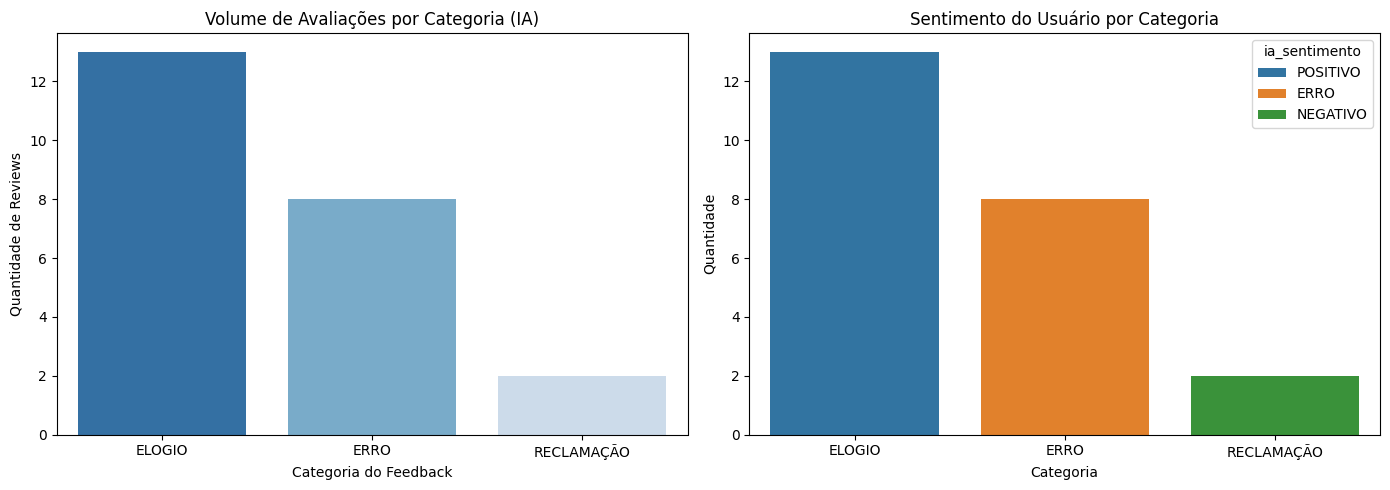

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ler o dado diretamente da camada analítica (Gold)
df_gold = pd.read_parquet('data_lake/gold/daily_ai_analysis_summary.parquet')

print("--- DADOS CONSOLIDADOS NA CAMADA GOLD ---")
print(df_gold.to_string(index=False))

# 2. Configurar a área dos gráficos
plt.figure(figsize=(14, 5))

# Gráfico 1: Distribuição de Categorias por IA
plt.subplot(1, 2, 1)
sns.barplot(data=df_gold, x='ia_categoria', y='total_reviews', estimator=sum, errorbar=None, palette='Blues_r')
plt.title('Volume de Avaliações por Categoria (IA)')
plt.xlabel('Categoria do Feedback')
plt.ylabel('Quantidade de Reviews')

# Gráfico 2: Sentimentos identificados dentro das categorias
plt.subplot(1, 2, 2)
sns.barplot(data=df_gold, x='ia_categoria', y='total_reviews', hue='ia_sentimento', estimator=sum, errorbar=None)
plt.title('Sentimento do Usuário por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Quantidade')

plt.tight_layout()
plt.show()